# Notebook 3 — Stationarity and Model Selection

## Objectives

- For each drug: perform **Augmented Dickey–Fuller (ADF)** test for stationarity.
- Apply **first differencing** and/or **seasonal differencing (lag = 12)** if needed.
- Plot **ACF** and **PACF** to inform AR/MA orders.
- Use **pmdarima.auto_arima** to select SARIMA(p, d, q)(P, D, Q, 12) per drug.
- Store optimal parameters in a dictionary.

**No forecasting in this notebook—model selection only.**

## 1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks" and (PROJECT_ROOT.parent / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name != "pharmacy_forecasting":
    PROJECT_ROOT = PROJECT_ROOT / "pharmacy_forecasting"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
DATA_PATH = OUTPUTS_DIR / "monthly_demand.csv"

df = pd.read_csv(DATA_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["drug_id", "month"]).reset_index(drop=True)
drug_ids = df["drug_id"].unique().tolist()
print("Drugs:", drug_ids)

Drugs: ['D001', 'D002', 'D003', 'D004', 'D005', 'D006', 'D007', 'D008', 'D009', 'D010']


## 2. Augmented Dickey–Fuller Test per Drug

In [2]:
def adf_report(series: pd.Series) -> dict:
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "adf_stat": result[0],
        "pvalue": result[1],
        "usedlag": result[2],
        "nobs": result[3],
        "critical_vals": result[4],
        "stationary": result[1] < 0.05,
    }

adf_results = {}
for drug_id in drug_ids:
    y = df[df["drug_id"] == drug_id]["monthly_demand"]
    adf_results[drug_id] = adf_report(y)
pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "critical_vals"} for k, v in adf_results.items()}).T

,adf_stat,pvalue,usedlag,nobs,stationary
D001,-4.72563,0.000075,1,34,True
D002,-6.204625,0.0,0,35,True
D003,-1.195944,0.675338,9,26,False
D004,-5.574253,0.000001,0,35,True
D005,-4.748227,0.000068,0,35,True
D006,-4.555902,0.000156,0,35,True
D007,-5.869265,0.0,0,35,True
D008,-4.218311,0.000613,0,35,True
D009,-0.222296,0.935811,10,25,False
D010,-4.434304,0.000258,0,35,True


## 3. First and Seasonal Differencing (if needed)

- If ADF suggests non-stationarity: apply first differencing (d=1) and/or seasonal differencing with lag=12 (D=1).
- We use **auto_arima** to choose d and D automatically; here we only illustrate ACF/PACF after differencing for one drug.

In [3]:
def get_series(df: pd.DataFrame, drug_id: str) -> pd.Series:
    sub = df[df["drug_id"] == drug_id][["month", "monthly_demand"]].set_index("month").sort_index()
    return sub["monthly_demand"].asfreq("MS").fillna(0)

# Example: first difference and seasonal difference (lag=12)
example_id = drug_ids[0]
y = get_series(df, example_id)
y_diff1 = y.diff().dropna()
y_diff_seasonal = y.diff(12).dropna()
y_diff_both = y.diff().diff(12).dropna()
print("ADF on original:", adf_report(y)["pvalue"])
print("ADF after diff(1):", adf_report(y_diff1)["pvalue"])
print("ADF after diff(12):", adf_report(y_diff_seasonal)["pvalue"])
print("ADF after diff(1).diff(12):", adf_report(y_diff_both)["pvalue"])

ADF on original: 7.530205032702993e-05
ADF after diff(1): 3.2076513313378034e-08
ADF after diff(12): 0.04511953387075182
ADF after diff(1).diff(12): 0.6558289134849398


## 4. ACF and PACF Plots

ACF/PACF help suggest AR (p, P) and MA (q, Q) orders. Seasonal lags (12, 24, ...) inform (P, Q).

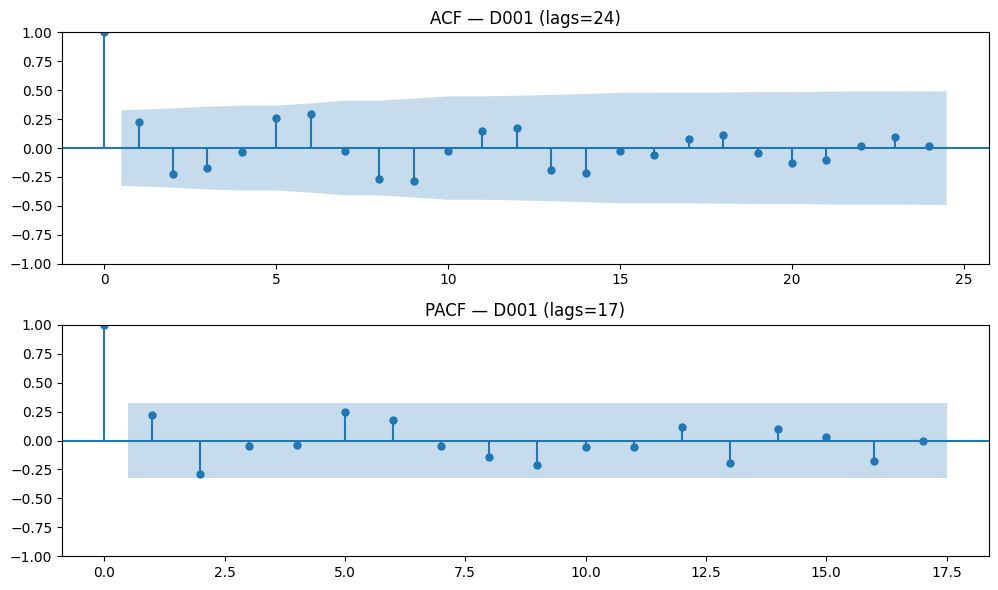

In [15]:
y = get_series(df, example_id).dropna()
n = len(y)

acf_lags = min(24, n - 2)                 # good for monthly seasonality
pacf_lags = min(17, (n // 2) - 1)         # must be < n//2

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(y, lags=acf_lags, ax=axes[0])
axes[0].set_title(f"ACF — {example_id} (lags={acf_lags})")

plot_pacf(y, lags=pacf_lags, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF — {example_id} (lags={pacf_lags})")

plt.tight_layout()
plt.show()

## 5. Auto ARIMA — SARIMA(p, d, q)(P, D, Q, 12)

Use **auto_arima** with seasonal=True, m=12 to get recommended orders per drug. Store in a dictionary.

In [16]:
# Seasonal period for monthly data
M = 12
# Store optimal (p,d,q)(P,D,Q,m) per drug
optimal_orders = {}

for drug_id in drug_ids:
    y = get_series(df, drug_id)
    model = auto_arima(
        y,
        seasonal=True,
        m=M,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False,
    )
    order = model.order
    seasonal_order = model.seasonal_order
    optimal_orders[drug_id] = {
        "order": order,
        "seasonal_order": seasonal_order,
        "full_order": (order, seasonal_order),
    }
    print(f"{drug_id}: SARIMA{order}{seasonal_order}")

D001: SARIMA(0, 0, 1)(0, 0, 1, 12)
D002: SARIMA(0, 0, 0)(0, 0, 0, 12)
D003: SARIMA(0, 0, 0)(0, 0, 1, 12)
D004: SARIMA(0, 0, 0)(0, 0, 0, 12)
D005: SARIMA(0, 0, 0)(0, 0, 0, 12)
D006: SARIMA(1, 0, 0)(2, 1, 0, 12)
D007: SARIMA(2, 1, 0)(1, 1, 0, 12)
D008: SARIMA(1, 0, 0)(0, 0, 0, 12)
D009: SARIMA(0, 0, 0)(1, 1, 0, 12)
D010: SARIMA(1, 0, 0)(0, 0, 0, 12)


In [17]:
# Summary table of optimal parameters
params_df = pd.DataFrame([
    {
        "drug_id": k,
        "p": v["order"][0],
        "d": v["order"][1],
        "q": v["order"][2],
        "P": v["seasonal_order"][0],
        "D": v["seasonal_order"][1],
        "Q": v["seasonal_order"][2],
        "m": v["seasonal_order"][3],
    }
    for k, v in optimal_orders.items()
])
params_df

,drug_id,p,d,q,P,D,Q,m
0,D001,0,0,1,0,0,1,12
1,D002,0,0,0,0,0,0,12
2,D003,0,0,0,0,0,1,12
3,D004,0,0,0,0,0,0,12
4,D005,0,0,0,0,0,0,12
5,D006,1,0,0,2,1,0,12
6,D007,2,1,0,1,1,0,12
7,D008,1,0,0,0,0,0,12
8,D009,0,0,0,1,1,0,12
9,D010,1,0,0,0,0,0,12


## 6. Save Optimal Orders for Next Notebooks

We save the optimal orders so that notebooks 4 and 5 can load them and fit SARIMA without re-running auto_arima.

In [18]:
import json

# Convert to JSON-serializable form
orders_serializable = {
    k: {"order": list(v["order"]), "seasonal_order": list(v["seasonal_order"])}
    for k, v in optimal_orders.items()
}
with open(OUTPUTS_DIR / "sarima_orders.json", "w") as f:
    json.dump(orders_serializable, f, indent=2)
params_df.to_csv(OUTPUTS_DIR / "sarima_orders.csv", index=False)
print("Saved: outputs/sarima_orders.json and outputs/sarima_orders.csv")

Saved: outputs/sarima_orders.json and outputs/sarima_orders.csv
